##Problem Statement
Title: E-Commerce Purchase Prediction
The objective of this project is to predict whether a customer will make a purchase based on their browsing behavior and session details. This is a classification problem where the target variable is “Purchase” (0 = No, 1 = Yes). The model helps businesses improve marketing strategies and increase conversion rates.



##Importing Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

 Importing pandas for data manipulation (DataFrame operations)

 Importing numpy for numerical computations

 Importing matplotlib for basic data visualization (plots, graphs)

 Importing seaborn for advanced and attractive visualizations

 Importing warnings module to handle warning messages

 Ignoring all warnings to keep output clean


##Upload Dataset

In [3]:
df = pd.read_csv("advanced_dataset.csv")

In [4]:
df.head()


,User_ID,Age,Gender,Session_Duration,Pages_Viewed,Product_Price,Previous_Purchases,Discount_Applied,Device_Type,Purchase
0,1.0,56.0,Male,40.0,13.0,3546.0,15.0,0.0,Desktop,0.0
1,2.0,46.0,Female,9.0,6.0,691.0,12.0,1.0,Desktop,1.0
2,3.0,32.0,Female,41.0,13.0,4728.0,10.0,0.0,Desktop,1.0
3,4.0,25.0,Male,34.0,18.0,2669.0,2.0,0.0,Mobile,0.0
4,5.0,38.0,Female,45.0,3.0,2972.0,7.0,1.0,Mobile,1.0


Check first 5 rows in dataset.

In [5]:
df.tail()

,User_ID,Age,Gender,Session_Duration,Pages_Viewed,Product_Price,Previous_Purchases,Discount_Applied,Device_Type,Purchase
4995,4996.0,32.0,Male,NaN,3.0,3314.0,3.0,0.0,Mobile,0.0
4996,4997.0,36.0,Female,12.0,14.0,2971.0,15.0,1.0,Desktop,1.0
4997,4998.0,52.0,NaN,23.0,9.0,4589.0,15.0,0.0,NaN,1.0
4998,4999.0,34.0,Female,15.0,8.0,4707.0,6.0,0.0,Desktop,0.0
4999,5000.0,52.0,Female,33.0,17.0,24405.0,12.0,0.0,Desktop,0.0


Check last 5 rows in dataset.

In [6]:
df.shape


(5000, 10)

Check the shape of the dataset i.e. rows and columns.

In [7]:
df.describe()


,User_ID,Age,Session_Duration,Pages_Viewed,Product_Price,Previous_Purchases,Discount_Applied,Purchase
count,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000,4750.000000
mean,2495.954737,38.721263,29.732421,10.157684,2645.420421,9.521474,0.477263,0.493684
std,1445.295969,12.049653,17.007170,5.508448,1980.145822,5.738260,0.499535,0.500013
min,1.000000,18.000000,1.000000,1.000000,100.000000,0.000000,0.000000,0.000000
25%,1248.250000,28.000000,15.000000,5.000000,1320.000000,4.000000,0.000000,0.000000
50%,2492.500000,39.000000,29.000000,10.000000,2522.000000,10.000000,0.000000,0.000000
75%,3744.750000,49.000000,44.000000,15.000000,3763.000000,14.000000,1.000000,1.000000
max,5000.000000,59.000000,59.000000,19.000000,24410.000000,19.000000,1.000000,1.000000


Generates statistical summary of numerical columns in the dataset


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   User_ID             4750 non-null   float64
 1   Age                 4750 non-null   float64
 2   Gender              4750 non-null   object 
 3   Session_Duration    4750 non-null   float64
 4   Pages_Viewed        4750 non-null   float64
 5   Product_Price       4750 non-null   float64
 6   Previous_Purchases  4750 non-null   float64
 7   Discount_Applied    4750 non-null   float64
 8   Device_Type         4750 non-null   object 
 9   Purchase            4750 non-null   float64
dtypes: float64(8), object(2)
memory usage: 390.8+ KB


df.info()-
Total number of entries (rows)

Column names

Non-null values count

Data type of each column (int, float, object)

Memory usage

In [9]:

df.drop(columns=['User_ID'], inplace=True)

Remove the unique column Id.

##Check Null Values

In [10]:
df.isnull().sum()

,0
Age,250
Gender,250
Session_Duration,250
Pages_Viewed,250
Product_Price,250
Previous_Purchases,250
Discount_Applied,250
Device_Type,250
Purchase,250


##Handling null values

In [11]:
# Numerical columns
num_cols = df.select_dtypes(exclude='object').columns
for col in num_cols:
    df[col].fillna(df[col].mean(), inplace=True)

# Categorical columns
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

“Numerical values were filled using mean and categorical values using mode to preserve data distribution.”

In [12]:
df.isnull().sum()

,0
Age,0
Gender,0
Session_Duration,0
Pages_Viewed,0
Product_Price,0
Previous_Purchases,0
Discount_Applied,0
Device_Type,0
Purchase,0


##Check Duplicates

In [13]:
df.duplicated().sum()


np.int64(0)

There is no duplicate values.

##Split Columns

In [14]:
cat_cols = df.select_dtypes(include='object').columns
num_cols = df.select_dtypes(exclude='object').columns

In [15]:
cat_cols

Index(['Gender', 'Device_Type'], dtype='object')

In [16]:
num_cols

Index(['Age', 'Session_Duration', 'Pages_Viewed', 'Product_Price',
       'Previous_Purchases', 'Discount_Applied', 'Purchase'],
      dtype='object')

##Outliers

In [17]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

After removing outliers shape is(4964,9)

In [18]:
df.shape


(4964, 9)

##Univarite Analysis

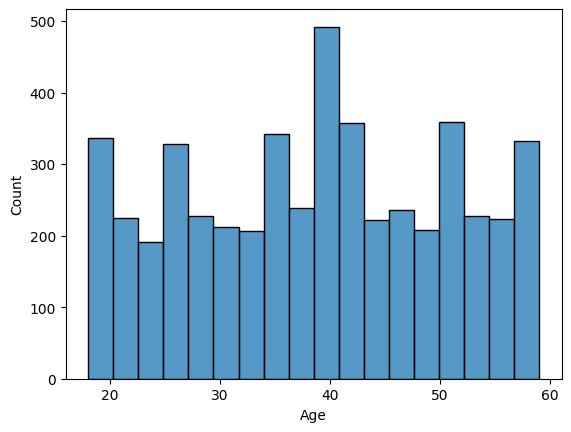

In [19]:
sns.histplot(df['Age'])
plt.show()





The age distribution is fairly uniform between 18 to 60, with no extreme skewness. This indicates that users of all age groups are using the platform.

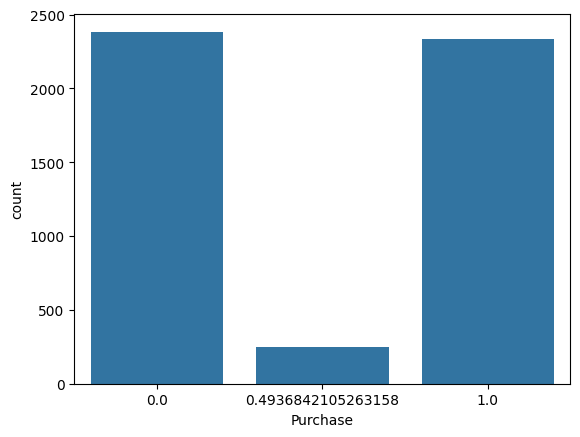

In [20]:
sns.countplot(x='Purchase', data=df)
plt.show()


The dataset is almost balanced between customers who made a purchase (1) and those who did not (0), which is good for training classification models.

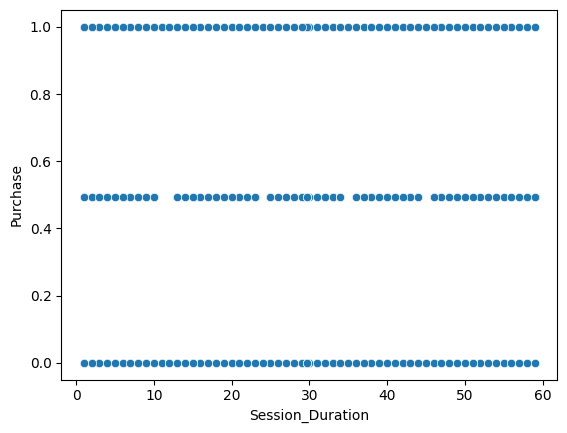

In [21]:
sns.scatterplot(x='Session_Duration', y='Purchase', data=df)
plt.show()

Customers with higher session duration show a higher tendency to purchase. The plot shows that as users spend more time, the probability of purchase increases.

In [22]:
df = pd.get_dummies(df, drop_first=True)


 Converting categorical variables into numerical using One-Hot Encoding
 drop_first=True is used to avoid dummy variable trap (multicollinearity)


In [23]:
cat_cols = df.select_dtypes(include='object').columns

In [24]:
cat_cols

Index([], dtype='object')

here i check all catogorical colmns are converted into numerical.

##Train test spilt

In [25]:
X = df.drop('Purchase', axis=1)
y = df['Purchase'].astype(int)


Divide dataset into the input and output variable.

X is the input removing purchase all other features are input.

y is the output. purchase is the only output.

In [26]:
from sklearn.model_selection import train_test_split


In [27]:
X_train,X_test, y_train, y_test = train_test_split(X,y,train_size = 0.8)

Splitting data into training (80%) and testing (20%)


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=1000)
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()

“I used Logistic Regression, Decision Tree, and Random Forest for classification.”

In [29]:
# Training models on training data

lr.fit(X_train, y_train)
dt.fit(X_train, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier()

In [30]:
# Making predictions on test data using trained models

y_pred_lr = lr.predict(X_test)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Logistic Regression
print("LR Accuracy:", accuracy_score(y_test, y_pred_lr))

# Decision Tree
print("DT Accuracy:", accuracy_score(y_test, y_pred_dt))

# Random Forest
print("RF Accuracy:", accuracy_score(y_test, y_pred_rf))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred_rf))

# Classification Report
print(classification_report(y_test, y_pred_rf))

LR Accuracy: 0.7915407854984894
DT Accuracy: 0.7230614300100705
RF Accuracy: 0.7784491440080564
[[430 121]
 [ 99 343]]
              precision    recall  f1-score   support

           0       0.81      0.78      0.80       551
           1       0.74      0.78      0.76       442

    accuracy                           0.78       993
   macro avg       0.78      0.78      0.78       993
weighted avg       0.78      0.78      0.78       993



In [32]:
best_model=lr

In [33]:
print(X.columns)


Index(['Age', 'Session_Duration', 'Pages_Viewed', 'Product_Price',
       'Previous_Purchases', 'Discount_Applied', 'Gender_Male',
       'Device_Type_Mobile'],
      dtype='object')


“I used the same column order as the training data using X.columns to avoid mismatch errors.”

In [34]:
new_data = pd.DataFrame([
    [28, 35, 12, 2000, 3, 1, 1, 1]
], columns=X.columns)

In [35]:
prediction = best_model.predict(new_data)
print(prediction)

[1]
